In [1]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set default figure size
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

### Step 1: Load the data
Load the UCI Online Retail file. The dataset contains transactional data from an online retailer in the UK.

In [3]:
df = pd.read_excel("online_retail.xlsx")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Step 2: Basic data overview
Check data types, missing values and general structure.

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Step 3: Data cleaning
- Remove rows with missing CustomerID (if we want to analyze customers).
- Remove returns (Quantity < 0) and invalid prices (UnitPrice <= 0).
- Add a TotalPrice column = Quantity * UnitPrice.
- Convert InvoiceDate to datetime format.

In [5]:
# 1. Remove rows with missing CustomerID
df_clean = df.dropna(subset=["CustomerID"])

# 2. Add TotalPrice column
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# 3. Remove returns and negative prices
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

# 4. Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print("Shape after cleaning:", df_clean.shape)
df_clean.head()

Shape after cleaning: (397884, 9)


/var/folders/vj/80n4z16s111b4kywc2l5x3tw0000gn/T/ipykernel_48380/2227906284.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [6]:
# 5. Standardize country names
print(sorted(df_clean["Country"].unique()))

['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Israel', 'Italy', 'Japan', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified']


In [7]:
country_rename = {
     "USA": "United States",
     "EIRE": "Ireland",
     "RSA" : "South Africa",
     "Unspecified": "Other",
     "European Community": "European Union",
}

print(sorted(df_clean["Country"].unique()))

['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Israel', 'Italy', 'Japan', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified']


### Step 4: Monthly sales trend
Check how sales evolve over time.
Create a Month column and group by it.

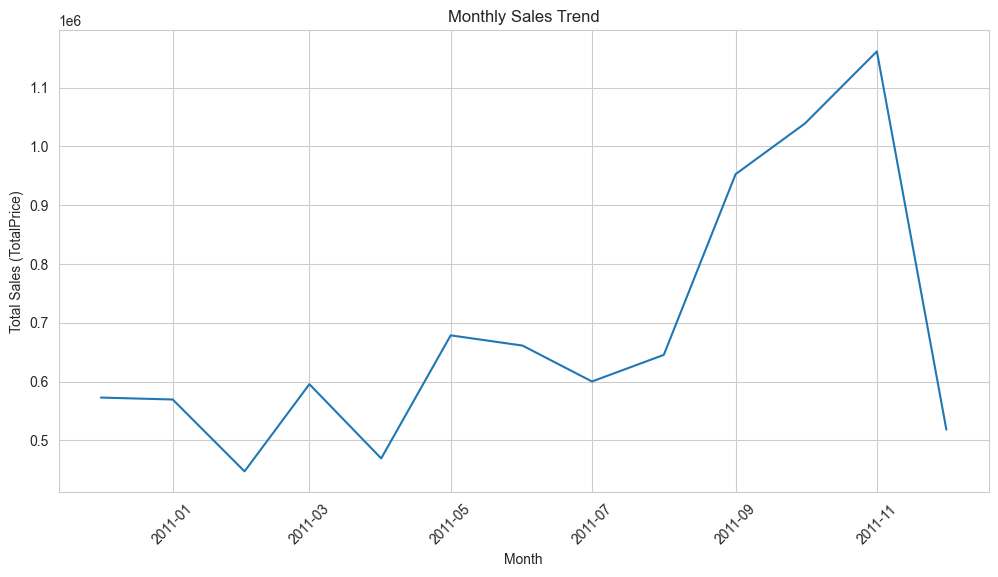

In [8]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df_clean.groupby("Month")["TotalPrice"]
    .sum()
    .reset_index()
)

monthly_sales["Month"] = monthly_sales["Month"].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x="Month", y="TotalPrice")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.ylabel("Total Sales (TotalPrice)")
plt.show()

### Step 5: Sales by country
Identify countries generating the highest revenue.

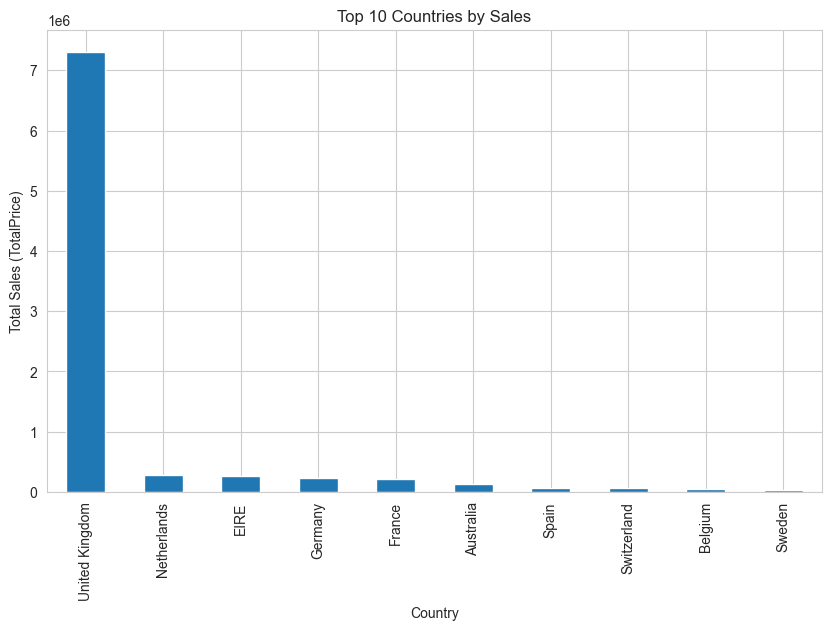

In [9]:
country_sales = (
    df_clean.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.ylabel("Total Sales (TotalPrice)")
plt.show()

### Step 6: Product analysis
Check which products generate the highest revenue.

In [10]:
df_clean = df[
    df["Description"].notna() &                          
    df["Description"].str.strip().eq("?") &            
    df["Description"].str.upper().str.contains(
        r"POSTAGE|DAMAGED|LOST|DISCOUNT|MANUAL|ADJUST|CRUK|BAD DEBT|AMAZON",
        na=False
    ) &
    (df["Quantity"] > 0) &                             
    (df["UnitPrice"] > 0)
].copy()

In [12]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("TotalPrice" in df_clean.columns)

True


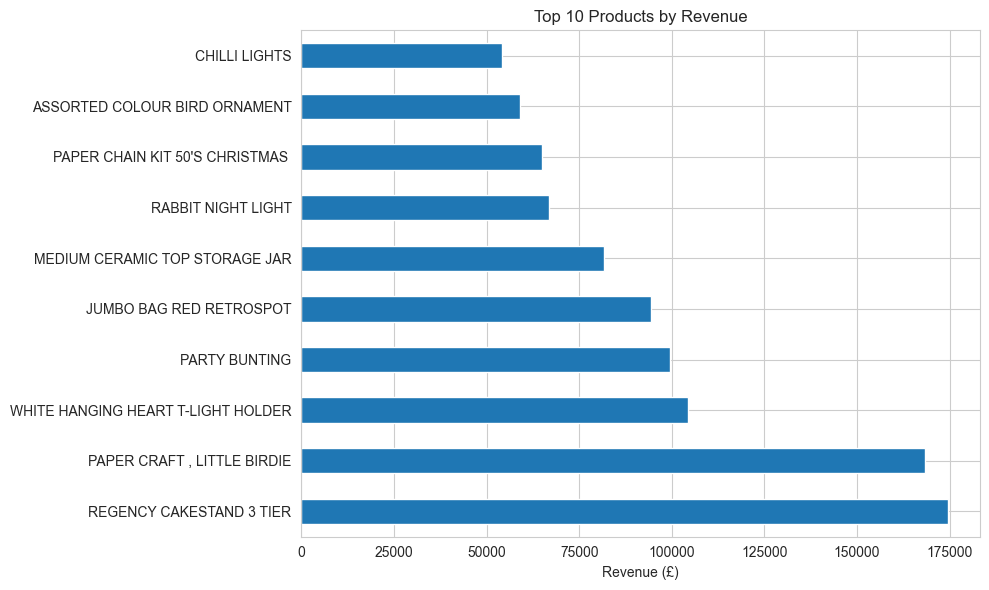

In [13]:
top_products = (
    df_clean.groupby(["StockCode", "Description"])["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products.plot(kind="barh", x="Description", y="TotalPrice", legend=False)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Step 7: Customer analysis (RFM‑style)
Create a simple customer profile:
- Recency: how many days since the last invoice,
- Frequency: number of invoices per customer,
- Monetary: total spending.

This is a simplified RFM approach without clustering.

In [14]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

print("RFM table shape:", rfm.shape)
rfm.head()

RFM table shape: (4335, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1437.24
3,12349.0,19,1,1457.55
4,12350.0,310,1,294.40


### Step 8: Customer segmentation (top 10%)
A simple segmentation based on Monetary:
- divide customers into 10 quantiles,
- select the top 10% (highest spenders).

Number of top 10% customers: 434


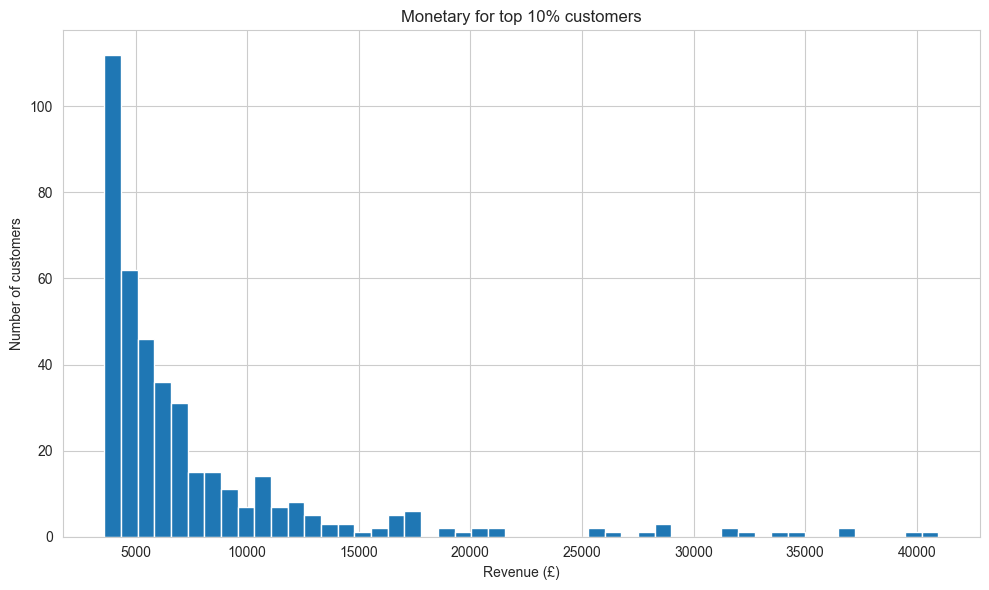

In [15]:
rfm["Monetary_q"] = pd.qcut(rfm["Monetary"], 10, labels=False)
top_customers = rfm[rfm["Monetary_q"] == 9]

print("Number of top 10% customers:", len(top_customers))

cap = top_customers["Monetary"].quantile(0.95)
top_customers[top_customers["Monetary"] <= cap]["Monetary"].plot(
    kind="hist", bins=50, title="Monetary for top 10% customers"
)
plt.xlabel("Revenue (£)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()